In [ ]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))
from paths import *


# Structure conditioning plus per-species LoRA


## Setup


In [1]:
# build_species.py geometry through gen_flat.py with a species LoRA merged
# in. three signals at once:
#   controlnet  line art, enforces where the organs sit
#   img2img     _flat.png, binds colour to position
#   lora        species appearance, prompted by its rare token
#
# the lora and controlnet compete for the same image. raising --scale
# suppresses the lora on surface texture; raising --lora-multiplier pulls
# off the drawn geometry. sweep both before committing.

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

PP   = str(ROOT)
BASE = str(ROOT)

%cd $PP
!nvidia-smi --query-gpu=name,memory.total --format=csv


Mounted at /content/drive
/content/drive/MyDrive/plant_pipeline
name, memory.total [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB


In [2]:
!pip install -q "diffusers>=0.31" "transformers>=4.44" accelerate safetensors opencv-python


## Config


In [ ]:
# token has to match the rare token in that species' training captions.
# if it doesn't, the lora merges but never initialised and base SDXL will
# respond to a meaningless rare-text token.
SPECIES = {
    "achillea":    {"token": "l35tgyhtew", "binomial": "Achillea maritima"},
    "eryngium":    {"token": "k92vbnqxdr", "binomial": "Eryngium maritimum"},
    "carpobrotus": {"token": "z47mfpwjhs", "binomial": "Carpobrotus acinaciformis"},
}

LORA = BASE + "/outputs/sdxl_{species}/lora.safetensors"

# The LoRA carries species identity, so the prompt no longer describes morphology. Keeping build_species.py's long descriptive prompt alongside the
# token would give SDXL two competing species signals.
PROMPT = ("a detailed realistic photograph of {subject} growing in sand dunes, "
          "natural daylight, sharp focus, fine leaf and petal detail, "
          "shot on a 100mm macro lens at f/8")

NEGATIVE = ("drawing, sketch, line art, illustration, cartoon, painting, "
            "flat colour, oversaturated, neon, lowres, worst quality, "
            "watermark, text, person, hands, floating plant, cut out, "
            "heavy bokeh, soft focus")

import os, glob
for s, v in SPECIES.items():
    p = LORA.format(species=s)
    n = len([f for f in glob.glob(f"out/{s}/*.png")
             if not f.endswith(("_flat.png", "_mask.png", "_control.png"))])
    print(f"{s:<14} lora {'ok ' if os.path.exists(p) else 'MISSING':<8} specs {n}")


achillea       lora ok       specs 200
eryngium       lora ok       specs 200
carpobrotus    lora ok       specs 200


## Check the patched script


In [4]:
# the original gen_flat.py has no --lora. if this errors, the patched
# version isn't in the pipeline folder.
!python gen_flat_lora.py --help | grep -E "lora|prompt|suffix|recursive"


usage: gen_flat_lora.py [-h] [--strength STRENGTH] [--scale SCALE]
                        [--no-recursive] [--lora LORA]
                        [--lora-multiplier LORA_MULTIPLIER] [--prompt PROMPT]
                        [--negative NEGATIVE] [--suffix SUFFIX] [-n N]
  --no-flat             ignore the flat map; ControlNet + prompt only
  --no-recursive        do not descend into subdirectories
  --lora LORA           a .safetensors LoRA to merge into the pipeline before
  --lora-multiplier LORA_MULTIPLIER
  --prompt PROMPT       override the per-spec .txt sidecar. With --lora this
  --suffix SUFFIX       extra suffix on output filenames, so a LoRA run does


## One test image


In [5]:
# before anything long-running. watch for the 'merged N/N modules' line.
TEST_SPECIES = "carpobrotus"

subject = SPECIES[TEST_SPECIES]["token"]
prompt  = PROMPT.format(subject=subject)
lora    = LORA.format(species=TEST_SPECIES)

%cd $PP
!python gen_flat_lora.py out/{TEST_SPECIES} \
    --lora "{lora}" --lora-multiplier 0.8 \
    --prompt "{prompt}" --negative "{NEGATIVE}" \
    --strength 0.85 --scale 0.75 \
    --suffix _lora -n 1 --out /tmp/loratest


/content/drive/MyDrive/plant_pipeline
150 spec(s), 1 image(s) each
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(

achillea_000.png  1024x1024  [controlnet+img2img +lora@0.8]
  a detailed realistic photograph of l35tgyhtew growing in sand dunes, natural daylight, sharp focus...
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:   0% 0/7 [00:00<?, ?it/s]
Loading weights:   0% 0/517 [00:00<?, ?it/s]
Loading weights:  39% 202/517 [00:00<00:00, 2018.09it/s]
Loading weights: 100% 517/517 [00:00<00:00, 2097.85it/s]
Loading pipeline components..

In [6]:
import glob
from IPython.display import Image, display

for f in sorted(glob.glob("/tmp/loratest/*.png")):
    if f.endswith("_control.png"):
        continue
    print(f)
    display(Image(f, width=340))


## Sweep


In [ ]:
# --scale against --lora-multiplier on one spec. want the cell where
# species texture is recognisable and the drawn structure survives. high on
# both gives a plant-shaped thing with the wrong surface, low on both
# drifts off the geometry.
SWEEP_SPECIES = "carpobrotus"
SCALES        = [0.5, 0.75, 1.0]
MULTIPLIERS   = [0.6, 0.8, 1.0]

# one specification solely, so the sweep is about parameters rather than seeds
specs = sorted(f for f in glob.glob(f"out/{SWEEP_SPECIES}/*.png")
               if not f.endswith(("_flat.png", "_mask.png", "_control.png")))
spec = specs[0]
print("sweeping on", spec)

subject = SPECIES[SWEEP_SPECIES]["token"]
prompt  = PROMPT.format(subject=subject)
lora    = LORA.format(species=SWEEP_SPECIES)

%cd $PP
for m in MULTIPLIERS:
    for s in SCALES:
        !python gen_flat_lora.py "{spec}" \
            --lora "{lora}" --lora-multiplier {m} \
            --prompt "{prompt}" --negative "{NEGATIVE}" \
            --strength 0.85 --scale {s} \
            --suffix _m{m}_s{s} -n 1 --seed 42 --out /tmp/sweep


sweeping on out/carpobrotus/carpobrotus_000.png
/content/drive/MyDrive/plant_pipeline
1 spec(s), 1 image(s) each
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:   0% 0/7 [00:00<?, ?it/s]
Loading weights: 100% 196/196 [00:00<00:00, 2955.38it/s]
Loading pipeline components...:  14% 1/7 [00:00<00:01,  4.81it/s]
Loading weights:   0% 0/517 [00:00<?, ?it/s]
Loading weights:  45% 232/517 [00:00<00:00, 2303.20it/s]
Loading weights: 100% 517/517 [00:00<00:00, 2249.85it/s]
Loading pipeline componen

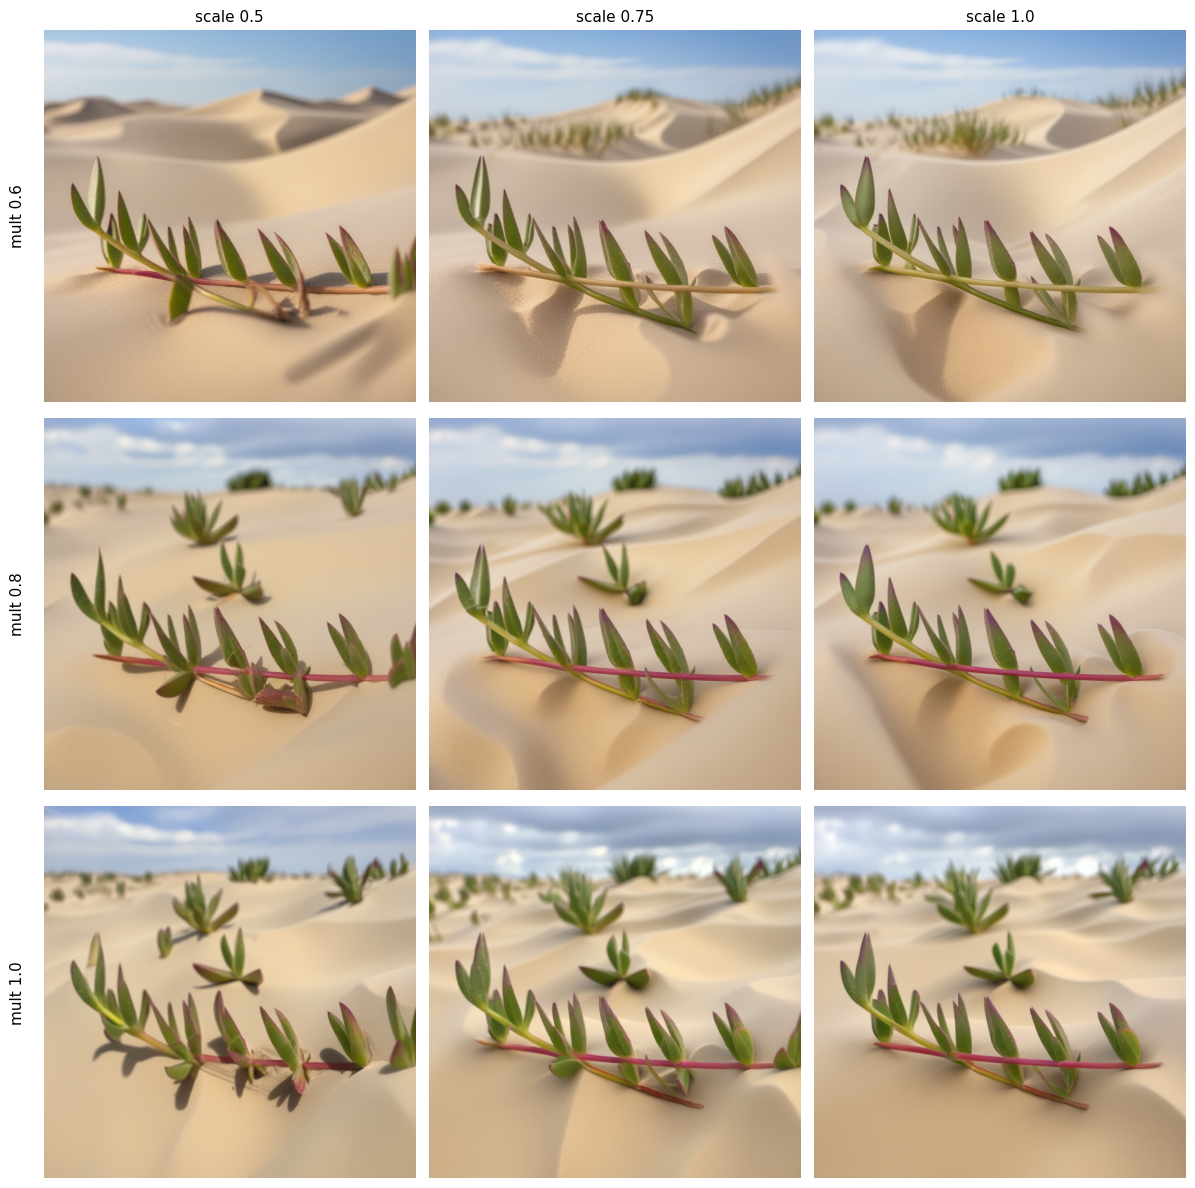

In [8]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage

fig, axes = plt.subplots(len(MULTIPLIERS), len(SCALES),
                         figsize=(4 * len(SCALES), 4 * len(MULTIPLIERS)))
axes = axes.reshape(len(MULTIPLIERS), len(SCALES))

for i, m in enumerate(MULTIPLIERS):
    for j, s in enumerate(SCALES):
        ax = axes[i, j]
        ax.axis("off")
        hits = glob.glob(f"/tmp/sweep/*_m{m}_s{s}_*.png")
        if hits:
            ax.imshow(PILImage.open(hits[0]))
        if i == 0:
            ax.set_title(f"scale {s}", fontsize=11)
        if j == 0:
            ax.text(-0.05, 0.5, f"mult {m}", transform=ax.transAxes,
                    rotation=90, va="center", ha="right", fontsize=11)

plt.tight_layout()
plt.savefig(f"{PP}/sweep_{SWEEP_SPECIES}.png", dpi=110, bbox_inches="tight")
plt.show()


## Full run


In [ ]:
# one species per call, each needs its own lora merged and a merge can't be undone 
# output lands beside the line art as <name>_lora_<seed>.png so it
# won't overwrite a base run.
SCALE_FINAL      = 0.75
MULTIPLIER_FINAL = 0.8
N_PER_SPEC       = 1

%cd $PP
for s in SPECIES:
    subject = SPECIES[s]["token"]
    prompt  = PROMPT.format(subject=subject)
    lora    = LORA.format(species=s)
    print(f"\n{'=' * 60}\n{s}\n{'=' * 60}")
    !python gen_flat_lora.py out/{s} \
        --lora "{lora}" --lora-multiplier {MULTIPLIER_FINAL} \
        --prompt "{prompt}" --negative "{NEGATIVE}" \
        --strength 0.85 --scale {SCALE_FINAL} \
        --suffix _lora -n {N_PER_SPEC} --seed 42


/content/drive/MyDrive/plant_pipeline

achillea
100 spec(s), 1 image(s) each
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(

achillea_000.png  1024x1024  [controlnet+img2img +lora@0.8]
  a detailed realistic photograph of l35tgyhtew growing in sand dunes, natural daylight, sharp focus...
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:   0% 0/7 [00:00<?, ?it/s]
Loading weights: 100% 196/196 [00:00<00:00, 2911.29it/s]
Loading pipeline components...:  71% 5/7 [00:01<00:00,  2.29it/s]
Loading weights:   0% 0/517 [00:00<?, ?it/s]
Loading we

## Review


In [ ]:
# line art, flat and generated side by side, to see what the structure
# conditioning kept
REVIEW_SPECIES = "carpobrotus"
N_REVIEW = 4

from PIL import Image as PILImage
from IPython.display import display

specs = sorted(f for f in glob.glob(f"out/{REVIEW_SPECIES}/*.png")
               if not f.endswith(("_flat.png", "_mask.png", "_control.png"))
               and "_lora_" not in f)

for spec in specs[:N_REVIEW]:
    stem = spec[:-4]
    gens = sorted(glob.glob(f"{stem}_lora_*.png"))
    if not gens:
        continue
    row = [PILImage.open(p).convert("RGB").resize((320, 320))
           for p in (spec, stem + "_flat.png", gens[0])]
    strip = PILImage.new("RGB", (960, 320))
    for k, im in enumerate(row):
        strip.paste(im, (k * 320, 0))
    print(os.path.basename(stem), "| line / flat / generated")
    display(strip)


## Base run for comparison


In [ ]:
# same geometry and prompt, no lora. gives the ablation: what does the lora contribute
# add over the of structure of conditioning alone
%cd $PP
for s in SPECIES:
    subject = SPECIES[s]["binomial"]     
    prompt  = PROMPT.format(subject=subject)
    !python gen_flat_lora.py out/{s} \
        --prompt "{prompt}" --negative "{NEGATIVE}" \
        --strength 0.85 --scale {SCALE_FINAL} \
        --suffix _nolora -n 1 --seed 42


## Copy to the rating site


In [ ]:
# renames sequentially and writes a manifest recording the source of each
# image, so ratings stay traceable
import json, shutil, hashlib

DEST = "/content/site_images"
FOLDERS = {"achillea": "images", "eryngium": "images_eryngium",
           "carpobrotus": "images_carpobrotus"}
CONDITION = "_lora"          # or "_nolora"

manifest = []
for species, folder in FOLDERS.items():
    d = os.path.join(DEST, folder)
    os.makedirs(d, exist_ok=True)
    gens = sorted(glob.glob(f"out/{species}/*{CONDITION}_*.png"))
    for i, src in enumerate(gens, start=1):
        shutil.copy(src, os.path.join(d, f"{i}.png"))
        manifest.append({
            "species": species,
            "site_path": f"/{folder}/{i}.png",
            "index": i,
            "source": src,
            "condition": f"structure{CONDITION}",
            "md5": hashlib.md5(open(src, "rb").read()).hexdigest(),
        })
    print(f"{species:<14} {len(gens)} -> {folder}/")

os.makedirs(DEST, exist_ok=True)
with open(os.path.join(DEST, "manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)
print(f"\nmanifest: {len(manifest)} entries")
